In [1]:
# Cell 1: Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Cell 2: Load Comments Dataset

comments_df = pd.read_csv("../data/comments.csv")

print("Comments dataset loaded successfully!")
print("Shape:", comments_df.shape)

comments_df.head()

Comments dataset loaded successfully!
Shape: (1790, 3)


,comment_id,content_id,comment
0,CM00001,C0001,You explained my situation perfectly.
1,CM00002,C0001,This hit me hard.
2,CM00003,C0001,This hit me hard.
3,CM00004,C0001,This was informative.
4,CM00005,C0002,I have been through the same thing.


In [3]:
# Cell 3: Inspect Comments Dataset

print("Column names:")
print(comments_df.columns.tolist())

print("\nDataset information:")
comments_df.info()

print("\nMissing values:")
print(comments_df.isnull().sum())

print("\nDuplicate rows:")
print(comments_df.duplicated().sum())

Column names:
['comment_id', 'content_id', 'comment']

Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 1790 entries, 0 to 1789
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   comment_id  1790 non-null   str  
 1   content_id  1790 non-null   str  
 2   comment     1790 non-null   str  
dtypes: str(3)
memory usage: 106.4 KB

Missing values:
comment_id    0
content_id    0
comment       0
dtype: int64

Duplicate rows:
0


In [4]:
# Cell 4: Clean Comments

# Remove rows where the comment is missing
comments_df = comments_df.dropna(subset=["comment"]).copy()

# Convert comments to string
comments_df["comment"] = comments_df["comment"].astype(str)

# Remove extra spaces
comments_df["comment"] = comments_df["comment"].str.strip()

# Remove empty comments
comments_df = comments_df[comments_df["comment"] != ""]

# Remove duplicate comments
comments_df = comments_df.drop_duplicates(subset=["comment"]).reset_index(drop=True)

print("Comments cleaned successfully!")
print("Remaining rows:", len(comments_df))

comments_df.head()

Comments cleaned successfully!
Remaining rows: 20


,comment_id,content_id,comment
0,CM00001,C0001,You explained my situation perfectly.
1,CM00002,C0001,This hit me hard.
2,CM00004,C0001,This was informative.
3,CM00005,C0002,I have been through the same thing.
4,CM00006,C0002,Finally someone talked about this.


In [5]:
# Cell 5: View Sample Comments

pd.set_option("display.max_colwidth", 200)

comments_df[["comment_id", "content_id", "comment"]].head(20)

,comment_id,content_id,comment
0,CM00001,C0001,You explained my situation perfectly.
1,CM00002,C0001,This hit me hard.
2,CM00004,C0001,This was informative.
3,CM00005,C0002,I have been through the same thing.
4,CM00006,C0002,Finally someone talked about this.
5,CM00008,C0002,This is literally me.
6,CM00009,C0003,Good information.
7,CM00010,C0003,Nice explanation.
8,CM00012,C0003,Interesting perspective.
9,CM00013,C0004,Interesting post.


In [6]:
# Cell 6: Create Text Features

# Number of characters in each comment
comments_df["comment_length"] = comments_df["comment"].str.len()

# Number of words in each comment
comments_df["word_count"] = comments_df["comment"].str.split().str.len()

# Convert text to lowercase
comments_df["clean_text"] = comments_df["comment"].str.lower()

print("Text features created successfully!")

comments_df[[
    "comment",
    "comment_length",
    "word_count",
    "clean_text"
]].head(10)

Text features created successfully!


,comment,comment_length,word_count,clean_text
0,You explained my situation perfectly.,37,5,you explained my situation perfectly.
1,This hit me hard.,17,4,this hit me hard.
2,This was informative.,21,3,this was informative.
3,I have been through the same thing.,35,7,i have been through the same thing.
4,Finally someone talked about this.,34,5,finally someone talked about this.
5,This is literally me.,21,4,this is literally me.
6,Good information.,17,2,good information.
7,Nice explanation.,17,2,nice explanation.
8,Interesting perspective.,24,2,interesting perspective.
9,Interesting post.,17,2,interesting post.


In [7]:
# Cell 7: Relatable vs Neutral Classification

relatable_words = [
    "me",
    "my situation",
    "my life",
    "same",
    "same thing",
    "same experience",
    "been through",
    "feel this",
    "felt this",
    "felt this way",
    "feel this way",
    "literally me",
    "this is me",
    "i relate",
    "relate",
    "relatable",
    "understand",
    "understood",
    "only one",
    "exactly how i feel",
    "described me",
    "described my",
    "my story",
    "my experience",
    "hit me",
    "hit hard",
    "situation perfectly",
    "going through",
    "been there"
]

def classify_comment(text):
    text = text.lower()

    for word in relatable_words:
        if word in text:
            return "Relatable"

    return "Neutral"


comments_df["relatability"] = comments_df["clean_text"].apply(classify_comment)

print("Classification completed!")

print("\nClass distribution:")
print(comments_df["relatability"].value_counts())

comments_df[["comment", "relatability"]].head(20)

Classification completed!

Class distribution:
relatability
Neutral      13
Relatable     7
Name: count, dtype: int64


,comment,relatability
0,You explained my situation perfectly.,Relatable
1,This hit me hard.,Relatable
2,This was informative.,Neutral
3,I have been through the same thing.,Relatable
4,Finally someone talked about this.,Relatable
5,This is literally me.,Relatable
6,Good information.,Neutral
7,Nice explanation.,Neutral
8,Interesting perspective.,Neutral
9,Interesting post.,Neutral


In [8]:
# Cell 8: Relatability Analysis

relatable_counts = comments_df["relatability"].value_counts()

print("Relatability Summary:")
print(relatable_counts)

print("\nRelatability Percentage:")
print((relatable_counts / len(comments_df) * 100).round(2))

Relatability Summary:
relatability
Neutral      13
Relatable     7
Name: count, dtype: int64

Relatability Percentage:
relatability
Neutral      65.0
Relatable    35.0
Name: count, dtype: float64


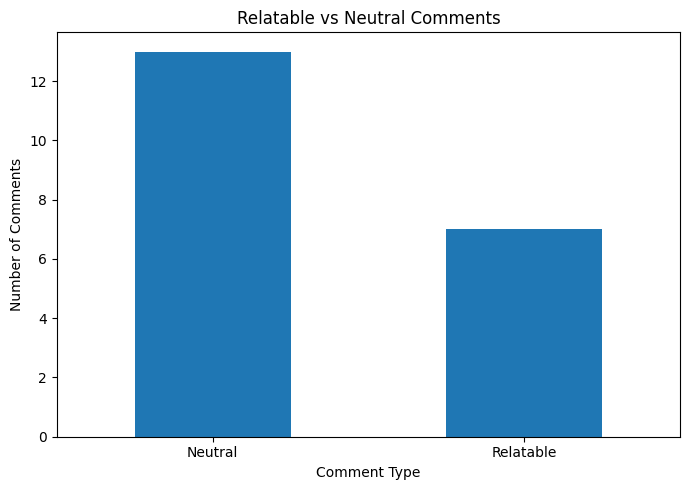

In [10]:
# Cell 9: Visualize Relatability

plt.figure(figsize=(7, 5))

comments_df["relatability"].value_counts().plot(kind="bar")

plt.title("Relatable vs Neutral Comments")
plt.xlabel("Comment Type")
plt.ylabel("Number of Comments")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [11]:
# Cell 10: Overall Relatability Rate

relatable_count = (comments_df["relatability"] == "Relatable").sum()
total_comments = len(comments_df)

relatable_rate = (relatable_count / total_comments) * 100

print(f"Total comments: {total_comments}")
print(f"Relatable comments: {relatable_count}")
print(f"Neutral comments: {total_comments - relatable_count}")
print(f"Relatability rate: {relatable_rate:.2f}%")

Total comments: 20
Relatable comments: 7
Neutral comments: 13
Relatability rate: 35.00%


In [12]:
# Cell 11: Relatability by Content

relatability_by_content = (
    comments_df.groupby("content_id")["relatability"]
    .value_counts()
    .unstack(fill_value=0)
)

relatability_by_content["Total Comments"] = relatability_by_content.sum(axis=1)

if "Relatable" in relatability_by_content.columns:
    relatability_by_content["Relatability Rate (%)"] = (
        relatability_by_content["Relatable"]
        / relatability_by_content["Total Comments"]
        * 100
    ).round(2)
else:
    relatability_by_content["Relatability Rate (%)"] = 0

relatability_by_content = relatability_by_content.sort_values(
    "Relatability Rate (%)",
    ascending=False
)

relatability_by_content

relatability,Neutral,Relatable,Total Comments,Relatability Rate (%)
content_id,,,,
C0002,0,3,3,100.00
C0005,0,1,1,100.00
C0001,1,2,3,66.67
C0014,1,1,2,50.00
C0004,2,0,2,0.00
C0003,3,0,3,0.00
C0006,1,0,1,0.00
C0007,3,0,3,0.00
C0009,1,0,1,0.00


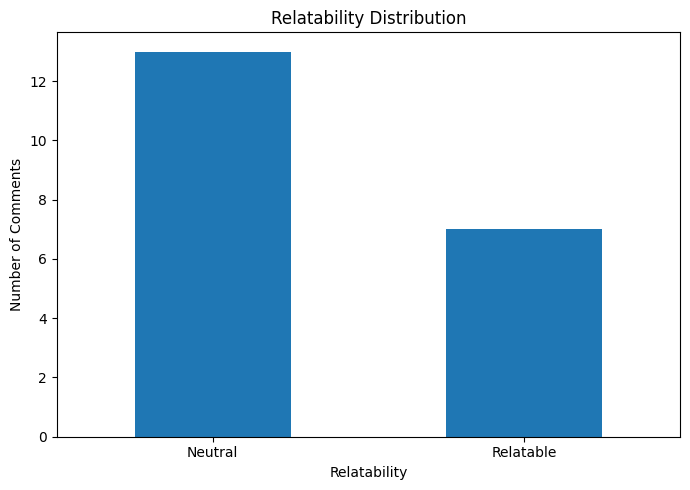

In [13]:
# Cell 12: Relatability Distribution

import matplotlib.pyplot as plt

relatability_counts = comments_df["relatability"].value_counts()

plt.figure(figsize=(7, 5))
relatability_counts.plot(kind="bar")

plt.title("Relatability Distribution")
plt.xlabel("Relatability")
plt.ylabel("Number of Comments")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [16]:
# Cell 13: Check Available Columns

print("Available columns:")
print(comments_df.columns.tolist())

Available columns:
['comment_id', 'content_id', 'comment', 'comment_length', 'word_count', 'clean_text', 'relatability']


In [17]:
# Cell 13: Comment Characteristics by Relatability

relatability_analysis = (
    comments_df.groupby("relatability")
    .agg(
        total_comments=("comment_id", "count"),
        avg_comment_length=("comment_length", "mean"),
        avg_word_count=("word_count", "mean")
    )
    .round(2)
)

relatability_analysis

,total_comments,avg_comment_length,avg_word_count
relatability,,,
Neutral,13,21.15,3.31
Relatable,7,31.86,6.00


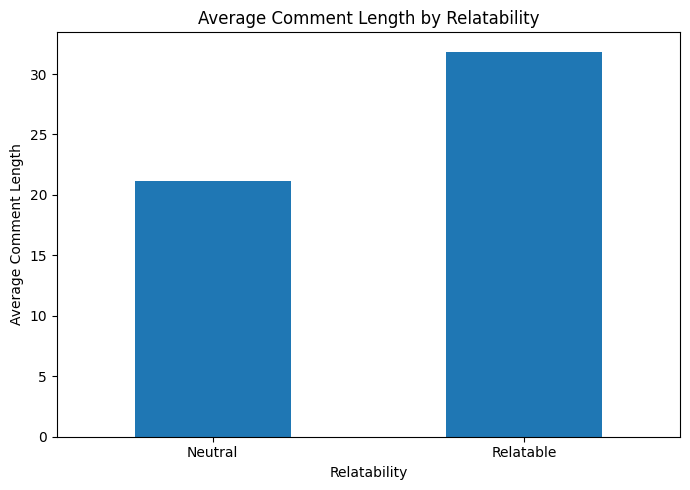

In [18]:
# Cell 14: Average Comment Length by Relatability

avg_length = comments_df.groupby("relatability")["comment_length"].mean()

plt.figure(figsize=(7, 5))
avg_length.plot(kind="bar")

plt.title("Average Comment Length by Relatability")
plt.xlabel("Relatability")
plt.ylabel("Average Comment Length")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

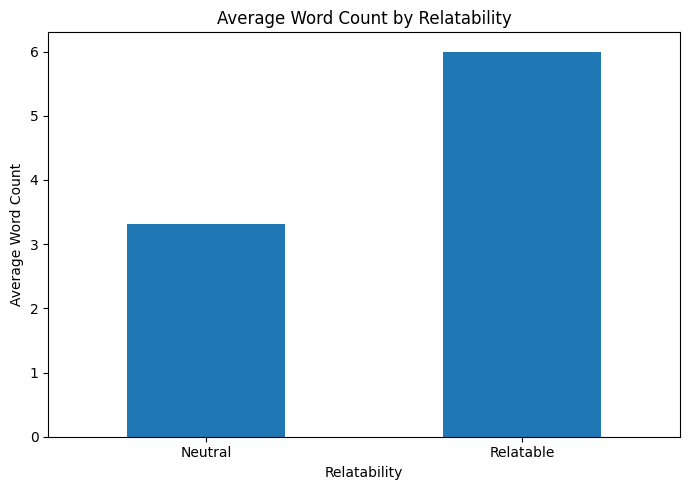

In [19]:
# Cell 15: Average Word Count by Relatability

avg_words = comments_df.groupby("relatability")["word_count"].mean()

plt.figure(figsize=(7, 5))
avg_words.plot(kind="bar")

plt.title("Average Word Count by Relatability")
plt.xlabel("Relatability")
plt.ylabel("Average Word Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [20]:
# Cell 16: Relatability Rate by Content

content_relatability = (
    comments_df.groupby("content_id")
    .agg(
        total_comments=("comment_id", "count"),
        relatable_comments=("relatability", lambda x: (x == "Relatable").sum())
    )
)

content_relatability["relatability_rate"] = (
    content_relatability["relatable_comments"]
    / content_relatability["total_comments"]
    * 100
).round(2)

content_relatability = content_relatability.sort_values(
    "relatability_rate",
    ascending=False
)

content_relatability

,total_comments,relatable_comments,relatability_rate
content_id,,,
C0002,3,3,100.00
C0005,1,1,100.00
C0001,3,2,66.67
C0014,2,1,50.00
C0004,2,0,0.00
C0003,3,0,0.00
C0006,1,0,0.00
C0007,3,0,0.00
C0009,1,0,0.00


In [21]:
# Cell 17: Top 10 Most Relatable Content

top_relatable_content = content_relatability.head(10)

top_relatable_content

,total_comments,relatable_comments,relatability_rate
content_id,,,
C0002,3,3,100.00
C0005,1,1,100.00
C0001,3,2,66.67
C0014,2,1,50.00
C0004,2,0,0.00
C0003,3,0,0.00
C0006,1,0,0.00
C0007,3,0,0.00
C0009,1,0,0.00


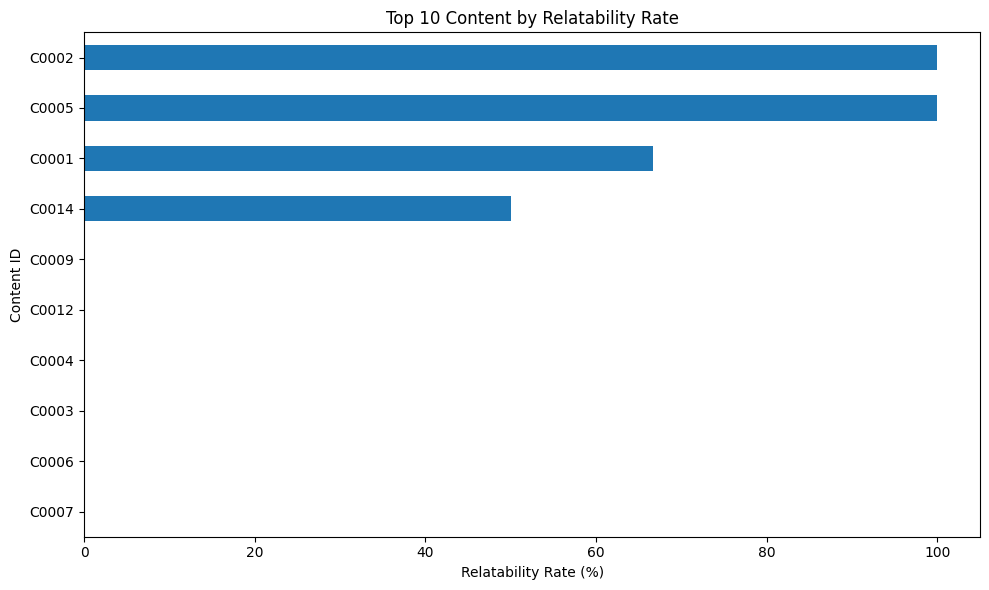

In [22]:
# Cell 18: Top 10 Relatable Content Visualization

plt.figure(figsize=(10, 6))

top_relatable_content["relatability_rate"].sort_values().plot(
    kind="barh"
)

plt.title("Top 10 Content by Relatability Rate")
plt.xlabel("Relatability Rate (%)")
plt.ylabel("Content ID")
plt.tight_layout()
plt.show()

In [23]:
# Cell 19: Relatability Summary

print("===== RELATABILITY SUMMARY =====")
print(f"Total comments: {len(comments_df)}")

relatable = (comments_df["relatability"] == "Relatable").sum()
neutral = (comments_df["relatability"] == "Neutral").sum()

print(f"Relatable comments: {relatable}")
print(f"Neutral comments: {neutral}")

print(f"Relatability rate: {(relatable / len(comments_df) * 100):.2f}%")

print("\nAverage comment length:")
print(comments_df.groupby("relatability")["comment_length"].mean().round(2))

print("\nAverage word count:")
print(comments_df.groupby("relatability")["word_count"].mean().round(2))

===== RELATABILITY SUMMARY =====
Total comments: 20
Relatable comments: 7
Neutral comments: 13
Relatability rate: 35.00%

Average comment length:
relatability
Neutral      21.15
Relatable    31.86
Name: comment_length, dtype: float64

Average word count:
relatability
Neutral      3.31
Relatable    6.00
Name: word_count, dtype: float64


In [24]:
# Cell 20: Save Relatability Analysis

content_relatability.to_csv(
    "content_relatability_analysis.csv"
)

relatability_analysis.to_csv(
    "relatability_summary.csv"
)

print("Relatability analysis files saved successfully.")

Relatability analysis files saved successfully.


In [25]:
# Cell 21: Verify Saved Files

import os

files_to_check = [
    "content_relatability_analysis.csv",
    "relatability_summary.csv"
]

for file in files_to_check:
    if os.path.exists(file):
        print(f"✓ {file} saved successfully")
    else:
        print(f"✗ {file} not found")

✓ content_relatability_analysis.csv saved successfully
✓ relatability_summary.csv saved successfully


In [26]:
# Cell 22: Relatability Distribution

relatability_distribution = (
    comments_df["relatability"]
    .value_counts()
    .reset_index()
)

relatability_distribution.columns = [
    "Relatability",
    "Number of Comments"
]

relatability_distribution["Percentage"] = (
    relatability_distribution["Number of Comments"]
    / relatability_distribution["Number of Comments"].sum()
    * 100
).round(2)

relatability_distribution

,Relatability,Number of Comments,Percentage
0,Neutral,13,65.0
1,Relatable,7,35.0


In [27]:
# Cell 23: Dashboard Relatability Metrics

dashboard_relatability = pd.DataFrame({
    "Metric": [
        "Total Comments",
        "Relatable Comments",
        "Neutral Comments",
        "Relatability Rate (%)",
        "Average Comment Length",
        "Average Word Count"
    ],
    "Value": [
        len(comments_df),
        (comments_df["relatability"] == "Relatable").sum(),
        (comments_df["relatability"] == "Neutral").sum(),
        round(
            (comments_df["relatability"] == "Relatable").mean() * 100,
            2
        ),
        round(comments_df["comment_length"].mean(), 2),
        round(comments_df["word_count"].mean(), 2)
    ]
})

dashboard_relatability

,Metric,Value
0,Total Comments,20.00
1,Relatable Comments,7.00
2,Neutral Comments,13.00
3,Relatability Rate (%),35.00
4,Average Comment Length,24.90
5,Average Word Count,4.25


In [28]:
# Cell 24: Save Dashboard Metrics

dashboard_relatability.to_csv(
    "dashboard_relatability_metrics.csv",
    index=False
)

print("Dashboard relatability metrics saved successfully.")

Dashboard relatability metrics saved successfully.


In [29]:
# Cell 25: Content-Level Summary

content_summary = (
    comments_df.groupby("content_id")
    .agg(
        total_comments=("comment_id", "count"),
        relatable_comments=(
            "relatability",
            lambda x: (x == "Relatable").sum()
        ),
        avg_comment_length=("comment_length", "mean"),
        avg_word_count=("word_count", "mean")
    )
)

content_summary["relatability_rate"] = (
    content_summary["relatable_comments"]
    / content_summary["total_comments"]
    * 100
).round(2)

content_summary["avg_comment_length"] = (
    content_summary["avg_comment_length"].round(2)
)

content_summary["avg_word_count"] = (
    content_summary["avg_word_count"].round(2)
)

content_summary = content_summary.sort_values(
    "total_comments",
    ascending=False
)

print("===== CONTENT-LEVEL SUMMARY =====")
display(content_summary)

===== CONTENT-LEVEL SUMMARY =====


,total_comments,relatable_comments,avg_comment_length,avg_word_count,relatability_rate
content_id,,,,,
C0001,3,2,25.00,4.00,66.67
C0002,3,3,30.00,5.33,100.00
C0003,3,0,19.33,2.00,0.00
C0007,3,0,19.33,3.33,0.00
C0014,2,1,33.00,7.50,50.00
C0004,2,0,32.50,5.00,0.00
C0006,1,0,11.00,2.00,0.00
C0005,1,1,32.00,6.00,100.00
C0009,1,0,15.00,2.00,0.00


In [30]:
# Cell 26: Save Content Summary

content_summary.to_csv(
    "content_summary.csv",
    index=True
)

print("Content summary saved successfully.")

Content summary saved successfully.


In [31]:
# Cell 27: Top 10 Content by Number of Comments

top_content = content_summary.head(10)

print("===== TOP 10 CONTENT BY COMMENTS =====")
display(top_content)

===== TOP 10 CONTENT BY COMMENTS =====


,total_comments,relatable_comments,avg_comment_length,avg_word_count,relatability_rate
content_id,,,,,
C0001,3,2,25.00,4.00,66.67
C0002,3,3,30.00,5.33,100.00
C0003,3,0,19.33,2.00,0.00
C0007,3,0,19.33,3.33,0.00
C0014,2,1,33.00,7.50,50.00
C0004,2,0,32.50,5.00,0.00
C0006,1,0,11.00,2.00,0.00
C0005,1,1,32.00,6.00,100.00
C0009,1,0,15.00,2.00,0.00


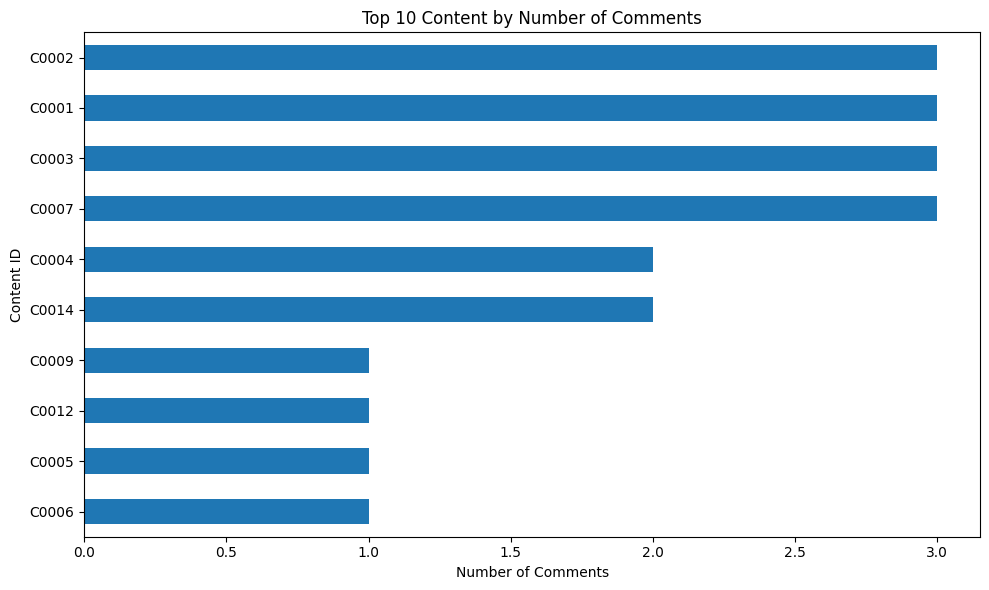

In [32]:
# Cell 28: Top 10 Content by Number of Comments

plt.figure(figsize=(10, 6))

top_content["total_comments"].sort_values().plot(
    kind="barh"
)

plt.title("Top 10 Content by Number of Comments")
plt.xlabel("Number of Comments")
plt.ylabel("Content ID")
plt.tight_layout()
plt.show()

In [33]:
# Cell 29: Relatable vs Neutral Comments by Content

relatability_content_counts = (
    comments_df.groupby(["content_id", "relatability"])
    .size()
    .unstack(fill_value=0)
)

# Keep only the top 10 content items by total comments
top_content_ids = content_summary.head(10).index

top_relatability_content = relatability_content_counts.loc[
    relatability_content_counts.index.intersection(top_content_ids)
]

print("===== RELATABLE VS NEUTRAL BY TOP CONTENT =====")
display(top_relatability_content)

===== RELATABLE VS NEUTRAL BY TOP CONTENT =====


relatability,Neutral,Relatable
content_id,,
C0001,1,2
C0002,0,3
C0003,3,0
C0004,2,0
C0005,0,1
C0006,1,0
C0007,3,0
C0009,1,0
C0012,1,0


<Figure size 1200x600 with 0 Axes>

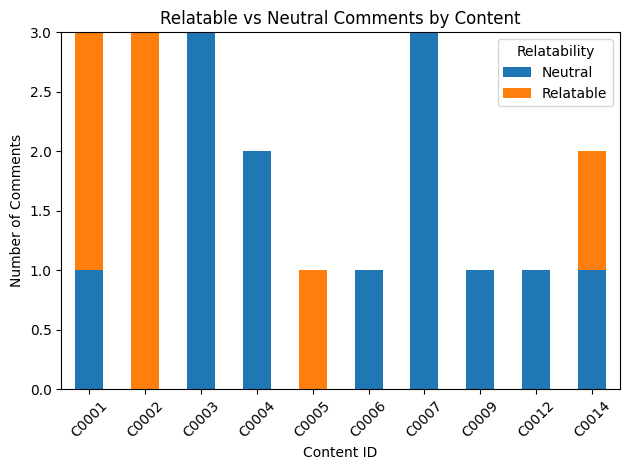

In [34]:
# Cell 30: Relatable vs Neutral Comments by Content

plt.figure(figsize=(12, 6))

top_relatability_content.plot(
    kind="bar",
    stacked=True
)

plt.title("Relatable vs Neutral Comments by Content")
plt.xlabel("Content ID")
plt.ylabel("Number of Comments")
plt.xticks(rotation=45)
plt.legend(title="Relatability")
plt.tight_layout()
plt.show()

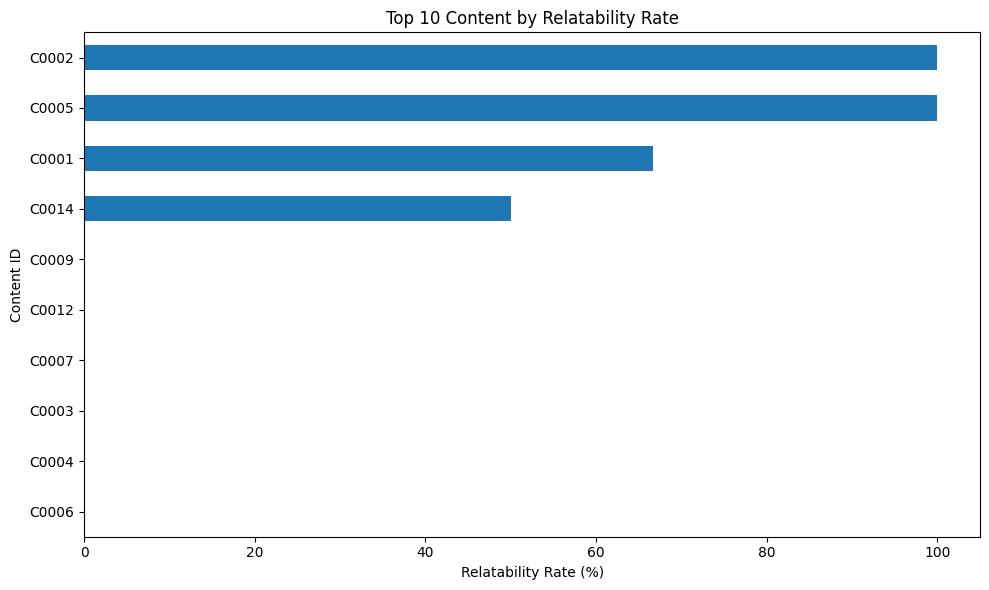

In [35]:
# Cell 31: Relatability Rate by Top Content

top_rate_content = (
    content_summary
    .sort_values("relatability_rate", ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 6))

top_rate_content["relatability_rate"].sort_values().plot(
    kind="barh"
)

plt.title("Top 10 Content by Relatability Rate")
plt.xlabel("Relatability Rate (%)")
plt.ylabel("Content ID")
plt.tight_layout()
plt.show()

In [36]:
# Cell 32: Content Performance Summary

content_performance = content_summary.copy()

content_performance["performance_rank"] = (
    content_performance["total_comments"]
    .rank(method="dense", ascending=False)
    .astype(int)
)

content_performance = content_performance.sort_values(
    ["total_comments", "relatability_rate"],
    ascending=[False, False]
)

print("===== CONTENT PERFORMANCE SUMMARY =====")
display(content_performance.head(10))

===== CONTENT PERFORMANCE SUMMARY =====


,total_comments,relatable_comments,avg_comment_length,avg_word_count,relatability_rate,performance_rank
content_id,,,,,,
C0002,3,3,30.00,5.33,100.00,1
C0001,3,2,25.00,4.00,66.67,1
C0003,3,0,19.33,2.00,0.00,1
C0007,3,0,19.33,3.33,0.00,1
C0014,2,1,33.00,7.50,50.00,2
C0004,2,0,32.50,5.00,0.00,2
C0005,1,1,32.00,6.00,100.00,3
C0006,1,0,11.00,2.00,0.00,3
C0009,1,0,15.00,2.00,0.00,3


In [37]:
# Cell 33: Save Final Content Performance Dataset

content_performance.to_csv(
    "content_performance.csv",
    index=True
)

print("Content performance dataset saved successfully.")

Content performance dataset saved successfully.


In [38]:
# Cell 34: Final Analysis Summary

print("=" * 50)
print("DATA-DRIVEN SOCIAL ENGAGEMENT ANALYSIS")
print("=" * 50)

print(f"\nTotal Comments: {len(comments_df)}")

relatable = (comments_df["relatability"] == "Relatable").sum()
neutral = (comments_df["relatability"] == "Neutral").sum()

print(f"Relatable Comments: {relatable}")
print(f"Neutral Comments: {neutral}")

relatability_rate = relatable / len(comments_df) * 100

print(f"Overall Relatability Rate: {relatability_rate:.2f}%")

print(
    f"\nAverage Comment Length: "
    f"{comments_df['comment_length'].mean():.2f}"
)

print(
    f"Average Word Count: "
    f"{comments_df['word_count'].mean():.2f}"
)

print(
    f"\nNumber of Unique Content Items: "
    f"{comments_df['content_id'].nunique()}"
)

print("\nTop 5 Content by Number of Comments:")
display(
    content_summary
    .sort_values("total_comments", ascending=False)
    .head(5)
)

print("\nAnalysis completed successfully.")

DATA-DRIVEN SOCIAL ENGAGEMENT ANALYSIS

Total Comments: 20
Relatable Comments: 7
Neutral Comments: 13
Overall Relatability Rate: 35.00%

Average Comment Length: 24.90
Average Word Count: 4.25

Number of Unique Content Items: 10

Top 5 Content by Number of Comments:


,total_comments,relatable_comments,avg_comment_length,avg_word_count,relatability_rate
content_id,,,,,
C0001,3,2,25.00,4.00,66.67
C0002,3,3,30.00,5.33,100.00
C0003,3,0,19.33,2.00,0.00
C0007,3,0,19.33,3.33,0.00
C0014,2,1,33.00,7.50,50.00



Analysis completed successfully.


In [41]:
# Cell 35: Find Existing DataFrames

dataframes = []

for name, obj in list(globals().items()):
    if isinstance(obj, pd.DataFrame):
        dataframes.append((name, obj))

print("DataFrames currently available:\n")

for name, df in dataframes:
    print(f"DataFrame: {name}")
    print(f"Shape: {df.shape}")
    print(f"Columns: {df.columns.tolist()}")
    print("-" * 60)

DataFrames currently available:

DataFrame: _
Shape: (6, 2)
Columns: ['Metric', 'Value']
------------------------------------------------------------
DataFrame: __
Shape: (2, 3)
Columns: ['Relatability', 'Number of Comments', 'Percentage']
------------------------------------------------------------
DataFrame: ___
Shape: (10, 3)
Columns: ['total_comments', 'relatable_comments', 'relatability_rate']
------------------------------------------------------------
DataFrame: comments_df
Shape: (20, 7)
Columns: ['comment_id', 'content_id', 'comment', 'comment_length', 'word_count', 'clean_text', 'relatability']
------------------------------------------------------------
DataFrame: _2
Shape: (5, 3)
Columns: ['comment_id', 'content_id', 'comment']
------------------------------------------------------------
DataFrame: _4
Shape: (5, 3)
Columns: ['comment_id', 'content_id', 'comment']
------------------------------------------------------------
DataFrame: _5
Shape: (20, 3)
Columns: ['comment_id'

In [42]:
# Cell 36: Find Candidate Content DataFrame

for name, obj in list(globals().items()):
    if isinstance(obj, pd.DataFrame):
        columns = [str(col).lower() for col in obj.columns]

        if (
            "content_id" in columns
            or "title" in columns
            or "category" in columns
            or "topic" in columns
        ):
            print(f"\nDataFrame name: {name}")
            print(f"Shape: {obj.shape}")
            print(f"Columns: {obj.columns.tolist()}")


DataFrame name: comments_df
Shape: (20, 7)
Columns: ['comment_id', 'content_id', 'comment', 'comment_length', 'word_count', 'clean_text', 'relatability']

DataFrame name: _2
Shape: (5, 3)
Columns: ['comment_id', 'content_id', 'comment']

DataFrame name: _4
Shape: (5, 3)
Columns: ['comment_id', 'content_id', 'comment']

DataFrame name: _5
Shape: (20, 3)
Columns: ['comment_id', 'content_id', 'comment']
